In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from adj import main, combine_graph_dict
from train import train_model
from utils import mclust_R, fix_seed

In [2]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score
from sklearn.metrics import v_measure_score as v_score
from utils import compute_PAS, compute_CHAOS
from sklearn.decomposition import PCA

In [3]:
fix_seed(1)

In [4]:
ROOT_PATH = Path('../data/MBA-MBP')
DATA_NAME = 'Mouse_Brain_Anterior'
adata_anterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_anterior.var_names_make_unique()

spatial_a=pd.read_csv("../data/MBA-MBP/Mouse_Brain_Anterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_anterior.obs["x_array"]=spatial_a[2]
adata_anterior.obs["y_array"]=spatial_a[3]
adata_anterior.obs["x_pixel"]=spatial_a[4]
adata_anterior.obs["y_pixel"]=spatial_a[5]
adata_anterior.obs['boundary'] = 0
# adata_anterior.obs['x_pixel'] = adata_anterior.obsm['spatial'][:,0]
# adata_anterior.obs['y_pixel'] = adata_anterior.obsm['spatial'][:,1]
# make spot name unique
adata_anterior.obs_names = [x + '_anterior' for x in adata_anterior.obs_names]

# adata_anterior.layers['count'] = adata_anterior.X.toarray()
# sc.pp.normalize_total(adata_anterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_anterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable'] == True]
# sc.pp.scale(adata_anterior)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable']]
adata_anterior

AnnData object with n_obs × n_vars = 2695 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
DATA_NAME = 'Mouse_Brain_Posterior'
adata_posterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_posterior.var_names_make_unique()

spatial_p=pd.read_csv("../data/MBA-MBP/Mouse_Brain_Posterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_posterior.obs["x_array"]=spatial_p[2]
adata_posterior.obs["y_array"]=spatial_p[3]
adata_posterior.obs["x_pixel"]=spatial_p[4]
adata_posterior.obs["y_pixel"]=spatial_p[5]
adata_posterior.obs['boundary'] = 0
# adata_posterior.obs['x_pixel'] = adata_posterior.obsm['spatial'][:,0]
# adata_posterior.obs['y_pixel'] = adata_posterior.obsm['spatial'][:,1]
# make spot name unique
adata_posterior.obs_names = [x + '_posterior' for x in adata_posterior.obs_names]

# adata_posterior.layers['count'] = adata_posterior.X.toarray()
# sc.pp.normalize_total(adata_posterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_posterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable'] == True]
# sc.pp.scale(adata_posterior)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable']]
adata_posterior

AnnData object with n_obs × n_vars = 3355 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [6]:
obs_a = adata_anterior.obs
obs_p = adata_posterior.obs
# obs_p["x_pixel"]=obs_p["x_pixel"]-np.min(obs_p["x_pixel"])+np.min(obs_a["x_pixel"])
obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) - 150
# obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) + 1500

obs_a["boundary"] = 0
obs_p["boundary"] = 0

for i in list(set(obs_a['x_array'])):
    j = obs_a[obs_a['x_array'] == i].max()["y_array"]
    temp = obs_a[obs_a['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_a.loc[temp, "boundary"] = 1

for i in list(set(obs_p['x_array'])):
    j = obs_p[obs_p['x_array'] == i].min()["y_array"]
    temp = obs_p[obs_p['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_p.loc[temp, "boundary"] = 1

mean_a_y = obs_a[obs_a["boundary"] == 1]['x_pixel'].mean()
mean_p_y = obs_p[obs_p["boundary"] == 1]['x_pixel'].mean()
obs_p['x_pixel'] = obs_p['x_pixel'] + mean_a_y - mean_p_y

In [7]:
adata_anterior.obsm["spatial_aligned"] = adata_anterior.obs.loc[adata_anterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()
adata_posterior.obsm["spatial_aligned"] = adata_posterior.obs.loc[adata_posterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()

In [8]:
list_adata = [adata_anterior, adata_posterior]

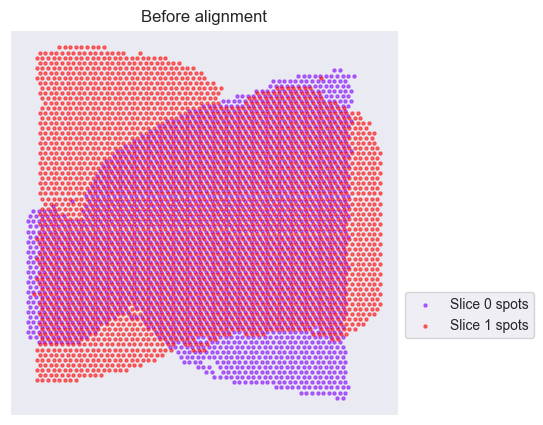

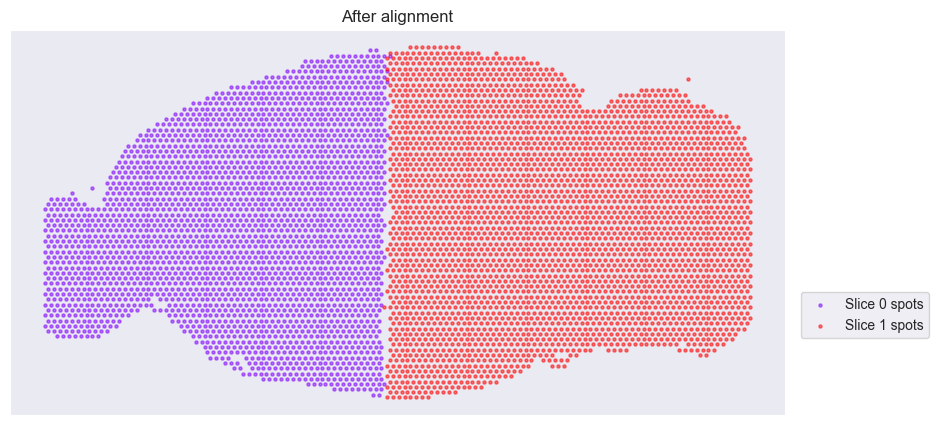

In [9]:
plot = True
coor_key = "spatial"
if plot:
    from matplotlib import cm
    import matplotlib
    import matplotlib.pyplot as plt

    # Choose colors
    cmap = cm.get_cmap('rainbow', len(list_adata))
    colors_list = [matplotlib.colors.rgb2hex(cmap(i)) for i in range(len(list_adata))]

    # Plot spots before alignment
    plt.figure(figsize=(5, 5))
    plt.title("Before alignment")
    for i in range(len(list_adata)):
        plt.scatter(list_adata[i].obsm[coor_key][:, 0],
                    list_adata[i].obsm[coor_key][:, 1],
                    c=colors_list[i],
                    label="Slice %d spots" % i, s=5., alpha=0.5)
    ax = plt.gca()
    ax.set_ylim(ax.get_ylim()[::-1])
    plt.xticks([])
    plt.yticks([])
    plt.legend(loc=(1.02, .2), ncol=(len(list_adata) // 13 + 1))
    plt.show()

if plot:
    plt.figure(figsize=(10, 5))
    plt.title("After alignment")
    for i in range(len(list_adata)):
        plt.scatter(list_adata[i].obsm["spatial_aligned"][:, 1],
                    list_adata[i].obsm["spatial_aligned"][:, 0],
                    c=colors_list[i],
                    label="Slice %d spots" % i, s=5., alpha=0.5)
    ax = plt.gca()
    ax.set_ylim(ax.get_ylim()[::-1])
    plt.xticks([])
    plt.yticks([])
    plt.legend(loc=(1.02, .2), ncol=(len(list_adata) // 13 + 1))
    plt.show()

In [10]:
import anndata as ad
pre_adata = ad.concat(list_adata, label="batch_name", keys=['anterior', 'posterior'])
pre_adata.obs["batch_name"] = pre_adata.obs["batch_name"].astype('category')
pre_adata

AnnData object with n_obs × n_vars = 6050 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name'
    obsm: 'spatial', 'spatial_aligned'

In [11]:
pre_adata.obs['batch_name']

AAACAAGTATCTCCCA-1_anterior      anterior
AAACACCAATAACTGC-1_anterior      anterior
AAACAGAGCGACTCCT-1_anterior      anterior
AAACAGCTTTCAGAAG-1_anterior      anterior
AAACAGGGTCTATATT-1_anterior      anterior
                                  ...    
TTGTTCAGTGTGCTAC-1_posterior    posterior
TTGTTGTGTGTCAAGA-1_posterior    posterior
TTGTTTCACATCCAGG-1_posterior    posterior
TTGTTTCATTAGTCTA-1_posterior    posterior
TTGTTTCCATACAACT-1_posterior    posterior
Name: batch_name, Length: 6050, dtype: category
Categories (2, object): ['anterior', 'posterior']

In [12]:
slice_name_list = list(pre_adata.obs['batch_name'].unique())
slice_name_list

['anterior', 'posterior']

In [13]:
for i, proj_name in enumerate(slice_name_list):
    
    adata_tmp = pre_adata[pre_adata.obs['batch_name'] == slice_name_list[i]]
    graph_dict_tmp = main(adata_tmp, adj_cons_by='coordinate', distType='KNN', k_cutoff=8, rad_cutoff=250)
    
    ##### Load layer_guess label, if have
    # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['layer_guess']
    # adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    #adata_tmp= adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]
    
    if proj_name == slice_name_list[0]:
        adata = adata_tmp
        graph_dict = graph_dict_tmp
        name = proj_name
        adata.obs['proj_name'] = proj_name
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['proj_name'] = proj_name
    
        adata = adata.concatenate(adata_tmp)
        graph_dict = combine_graph_dict(graph_dict, graph_dict_tmp)
        name = name + '_' + proj_name

------Calculating spatial graph...
The graph contains 21560 edges, 2695 cells.
8.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 26840 edges, 3355 cells.
8.0000 neighbors per cell on average.


In [14]:
adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=1000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [15]:
SpaBatch_net = train_model(adata, graph_dict, pre_epochs=400 ,epochs=500, mask_rate=0.2)
using_dec = True
if using_dec:
    SpaBatch_net.train_with_dec(num_aggre=2)
else:
    SpaBatch_net.train_without_dec()

Epoch 399 total loss=4.832: 100%|██████████ [ time left: 00:00 ]     
Epoch 499 total loss=3.675 recon loss=3.064 kl loss=0.042 tri loss=0.195 : |           [ time left: 00:00 ]    


In [16]:
SpaBatch_feat, _ = SpaBatch_net.process()
adata.obsm['SpaBatch'] = SpaBatch_feat

In [17]:
mclust_R(adata, num_cluster=32, used_obsm='SpaBatch')

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 6050 × 1000
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name', 'proj_name', 'batch', 'mclust'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'spatial_aligned', 'X_pca', 'Tri_SEDR', 'SEDR'
    layers: 'count'

In [18]:
adata1 = adata[adata.obs['batch_name'] == 'anterior']
# sc.pl.spatial(adata1, img_key=None, color=['mclust'], title=[''],
#               legend_loc=None, legend_fontsize=12, show=False, frameon=False,
#               spot_size=100)

In [19]:
df_label = pd.read_csv('../data/MBA-MBP/Mouse_Brain_Anterior/Manual_annotations.tsv', sep='\t',  index_col=0)
#转换index名称
index = [s + '_anterior-0' for s in df_label.index]
df_label.index = index
adata1.obs["layer_guess"] = df_label['ground_truth']

In [20]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
ARI = ari_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total ARI:{ARI}")
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
NMI = nmi_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total AMI:{AMI}")
ACC = 1/2 * (NMI + AMI)
print(f"total ACC:{ACC}")
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
HOM = hom_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total COM:{COM}")
V = 2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total ARI:0.42854570025760996
total NMI:0.6552610458887163
total AMI:0.6300729693041304
total ACC:0.6426670075964234
total HOM:0.5905997646840532
total COM:0.735821834044718
total V:0.6552610458887163


In [21]:
# adata2 = adata[adata.obs['batch_name'] == 'posterior']
# sc.pl.spatial(adata2, img_key=None, color=['mclust'], title=[''],
#               legend_loc=None, legend_fontsize=12, show=False, frameon=False,
#               spot_size=100)

In [22]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# 
# # 绘制第一个批次的空间图
# sc.pl.spatial(adata1, ax=axes[0], img_key=None, color=['mclust'], title=['Anterior'],
#               legend_loc='center right', legend_fontsize=12, show=False, frameon=False,
#               spot_size=150)
# 
# # 绘制第二个批次的空间图
# sc.pl.spatial(adata2, ax=axes[1], img_key=None, color=['mclust'], title=['Posterior'],
#               legend_loc='best', legend_fontsize=12, show=False, frameon=False,
#               spot_size=150)
# 
# # 显示图像
# plt.tight_layout()
# plt.show()

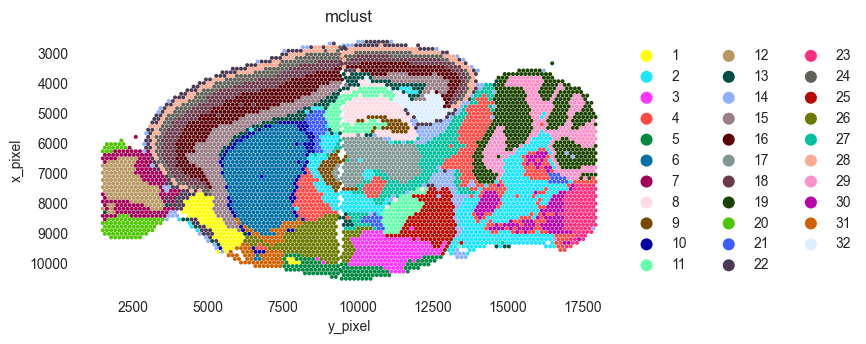

In [31]:
import matplotlib.pyplot as plt

plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

title = "SpaBatch"
subadata = adata[~adata.obs['mclust'].isna()]  # 删除 NaN
ax=sc.pl.scatter(subadata,alpha=1,x="y_pixel",y="x_pixel",color="mclust",show=False,size=200000/adata.shape[0])
ax.set_aspect('equal', 'box')
ax.axes.invert_yaxis()
plt.grid(False)

In [45]:
adata

AnnData object with n_obs × n_vars = 6050 × 1000
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name', 'proj_name', 'batch', 'mclust'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg'
    obsm: 'spatial', 'spatial_aligned', 'X_pca', 'Tri_SEDR', 'SEDR'
    layers: 'count'

In [26]:
#adata.write('Our_MBA_MBP.h5ad')

In [5]:
adata = sc.read_h5ad('Our_MBA_MBP.h5ad')

In [6]:
adata.obs['mclust'] = adata.obs['mclust'].astype(str)

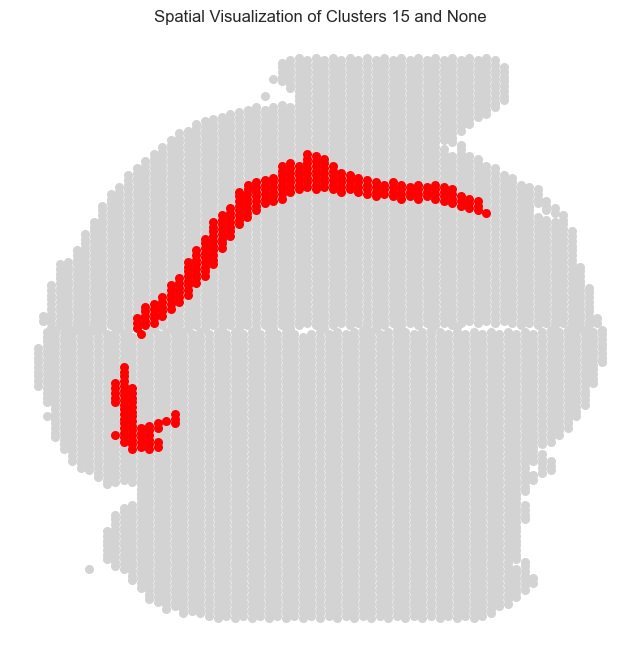

In [26]:
# 获取坐标信息
x = adata.obsm['spatial_aligned'][:, 0]  # X坐标
y = adata.obsm['spatial_aligned'][:, 1]  # Y坐标

# 获取聚类信息
cluster_labels = adata.obs['mclust'].astype(str)

# 选择目标空间域 (例如，聚类标签为 '1' 和 '2')
target_cluster_1 = '15'
target_cluster_2 = None

# 创建布尔掩码
is_target_1 = cluster_labels == target_cluster_1
is_target_2 = cluster_labels == target_cluster_2

# 绘图
plt.figure(figsize=(8, 8))



# 绘制背景 (不是目标空间域的点)
plt.scatter(x[~is_target_1 & ~is_target_2], y[~is_target_1 & ~is_target_2], c='lightgray', s=30, label='Background', alpha=1.)

# 绘制目标空间域 1 (标签为 1 的点)
plt.scatter(x[is_target_1], y[is_target_1], c='red', s=30, label=f'Cluster {target_cluster_1}', alpha=1.)

# 绘制目标空间域 2 (标签为 2 的点)
#plt.scatter(x[is_target_2], y[is_target_2], c='Orange', s=30, label=f'Cluster {target_cluster_2}', alpha=1.)

# 反转Y轴 (符合空间转录组学的显示习惯)
plt.gca().invert_yaxis()

# 添加图例和标题
#plt.legend()
plt.title(f"Spatial Visualization of Clusters {target_cluster_1} and {target_cluster_2}")
plt.axis('off')  # 去除坐标轴
plt.show()

In [27]:
sc.tl.rank_genes_groups(adata, 'mclust', groups=['15'], reference='1', key_added = "15vs1")

In [28]:
cut_log2fc_min = 2

g_list = list(sc.get.rank_genes_groups_df(adata, group='15', key='15vs1', pval_cutoff=0.05, log2fc_min=cut_log2fc_min)['names'])
g_list

['Vxn',
 'Ccl27a',
 'Hpcal4',
 'Ncald',
 'Tmsb10',
 'Pcsk2',
 'Ipcef1',
 'Mpped1',
 'Atp2b4',
 'Ccn2',
 'Lmo4',
 'Hs3st2',
 'Nr4a2',
 'Homer1',
 'Pgm2l1',
 'B3galt2',
 'Epop',
 'Igfbp6',
 'Hs3st4',
 'Rab26',
 'Arpp19',
 'Prss12',
 'Sstr2',
 'Sema5b',
 'Gabbr2',
 'Foxg1',
 'Cobl',
 'Camkv',
 'Egr3',
 'Mctp1',
 'Prss23',
 'Pcp4',
 'Hrh3',
 'Npy',
 'Cort',
 'Ptpn4',
 'Ndnf',
 'Rarb',
 'Pacsin2',
 'Pnmal2',
 'Gucy1a1',
 'Cacng5',
 'Rbp1',
 'Gabra2',
 'Rora',
 'Pcp4l1']

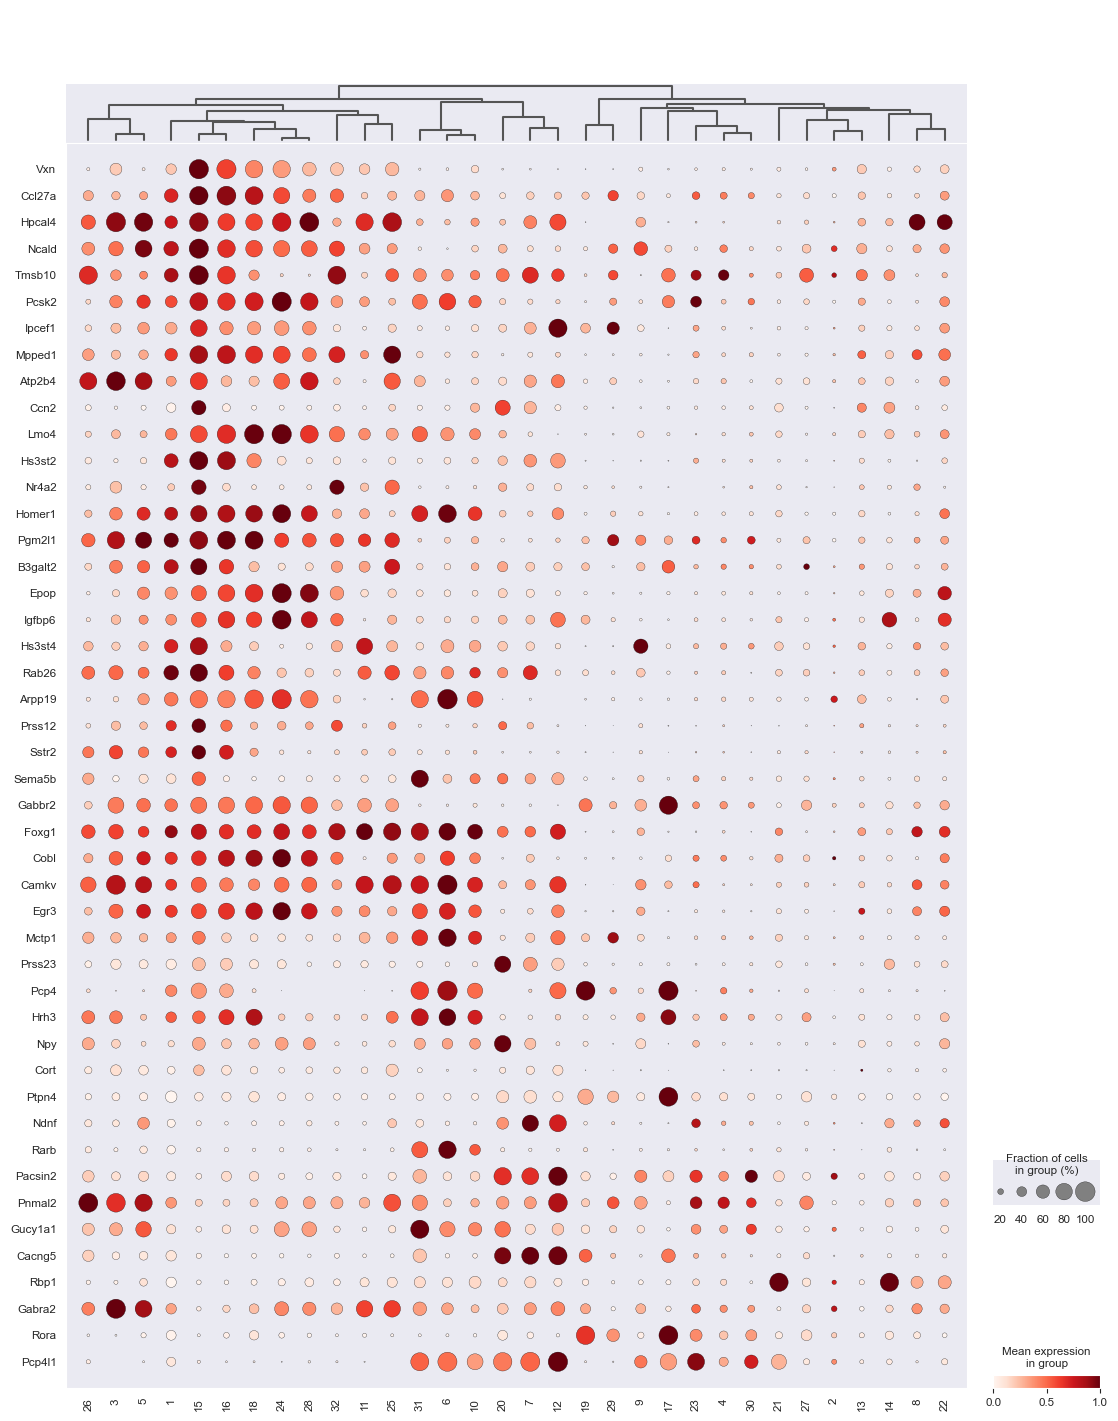

In [29]:
sc.pl.dotplot(adata, g_list, groupby='mclust', dendrogram=True, swap_axes=True,standard_scale='var')

True


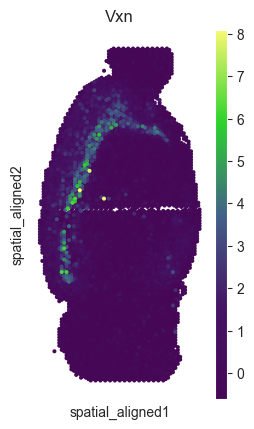

True


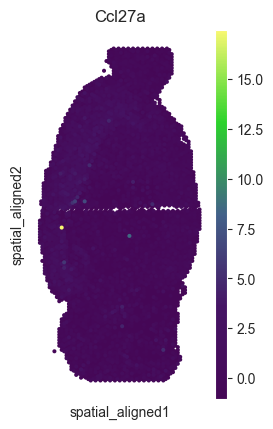

True


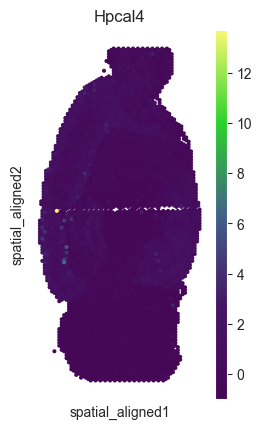

True


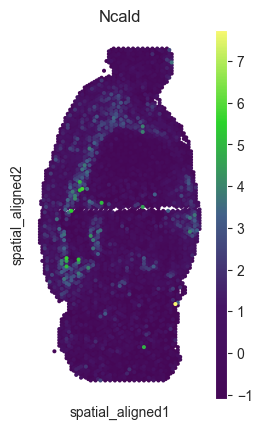

True


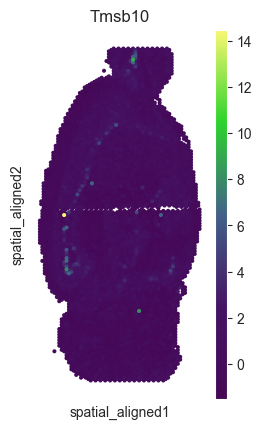

True


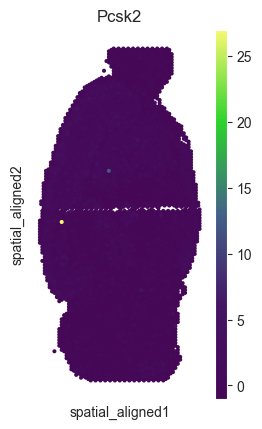

True


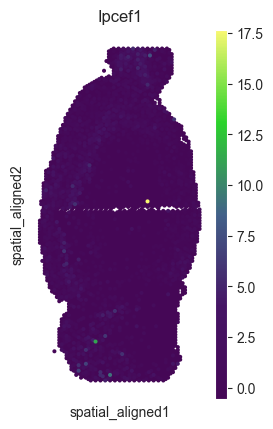

True


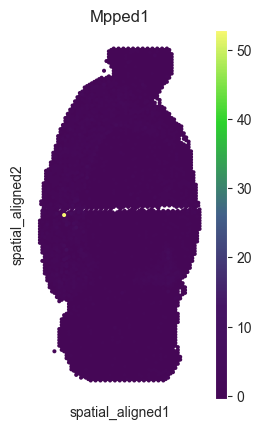

True


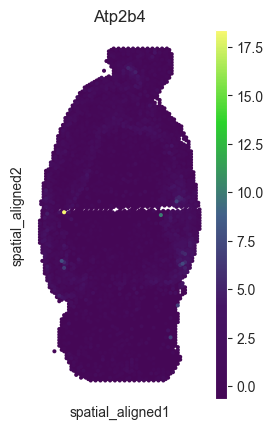

True


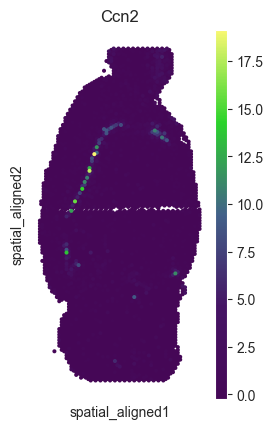

True


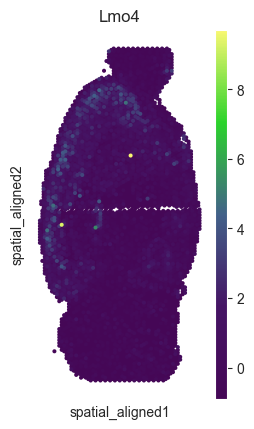

True


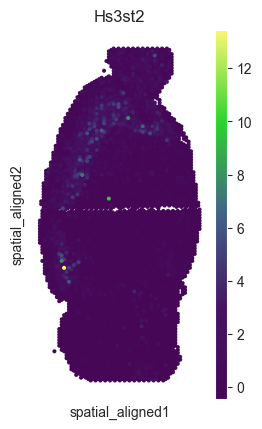

True


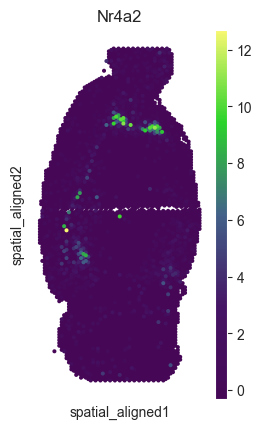

True


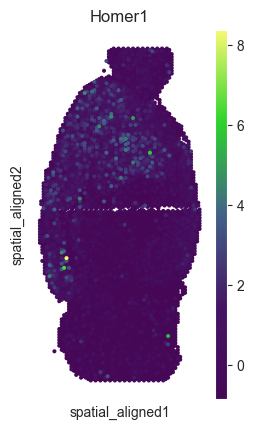

True


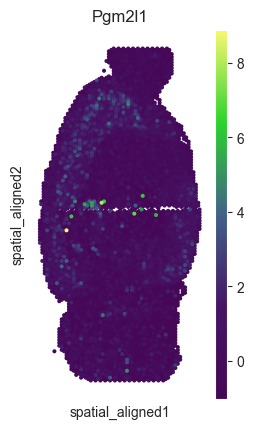

True


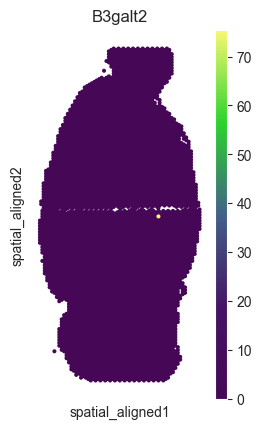

True


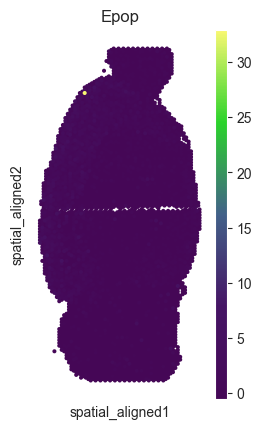

True


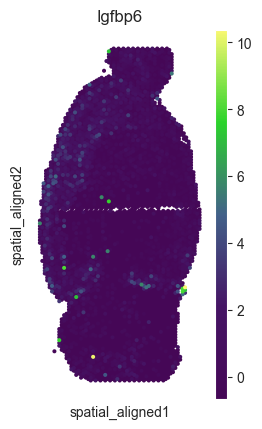

True


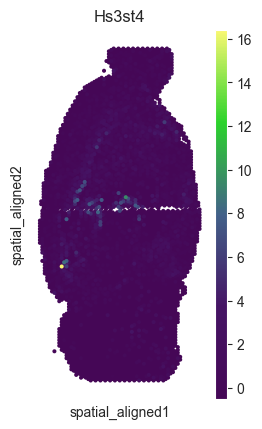

True


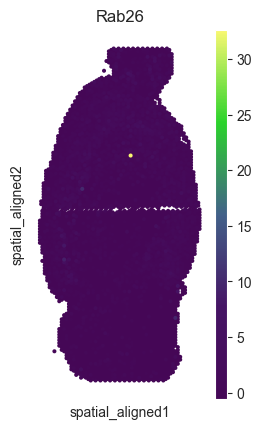

True


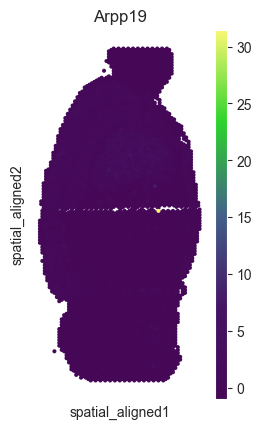

True


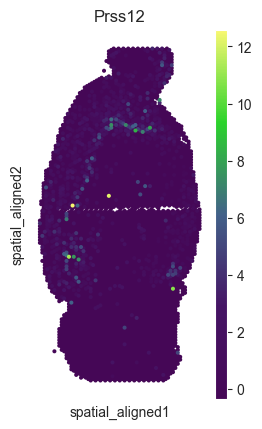

True


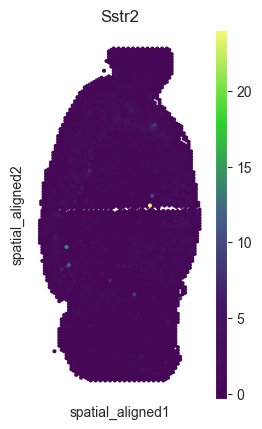

True


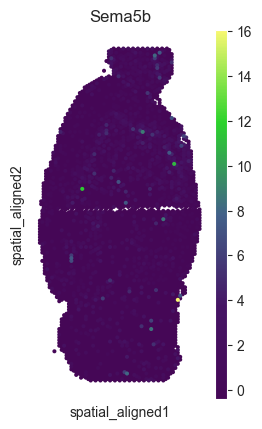

True


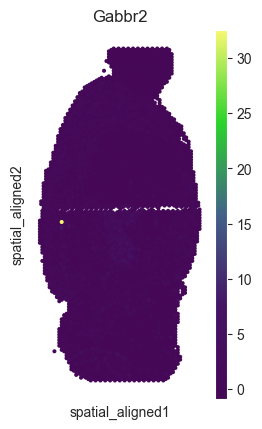

True


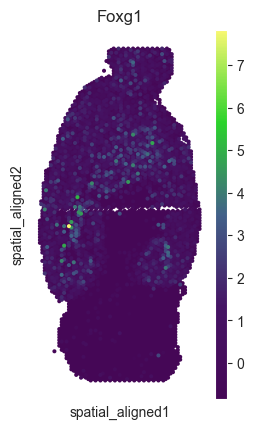

True


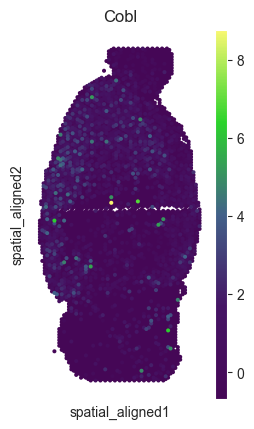

True


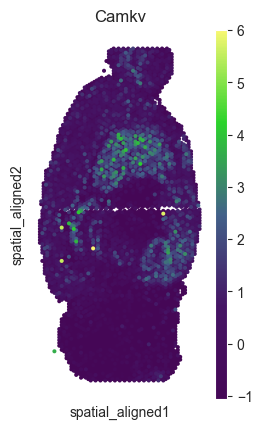

True


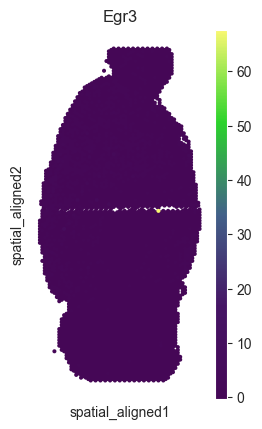

True


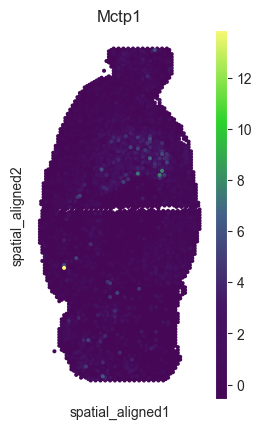

True


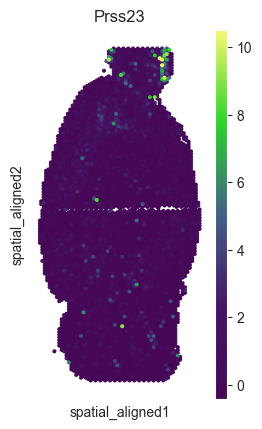

True


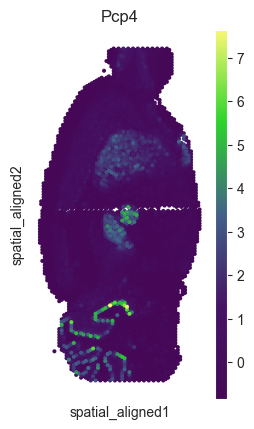

True


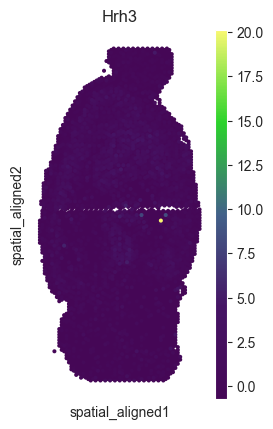

True


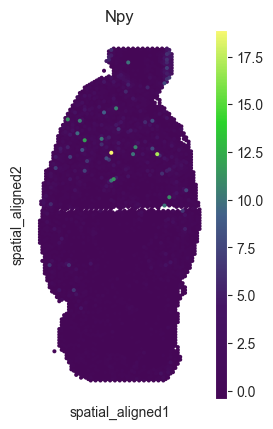

True


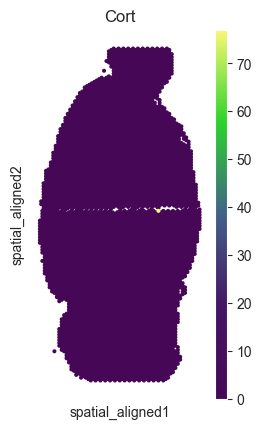

True


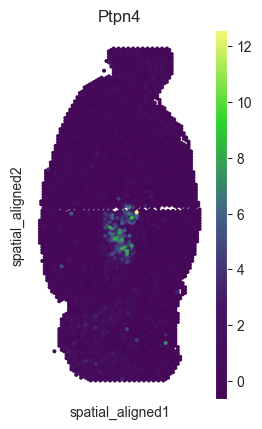

True


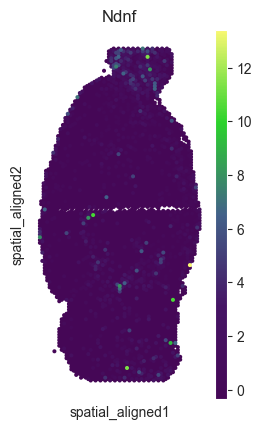

True


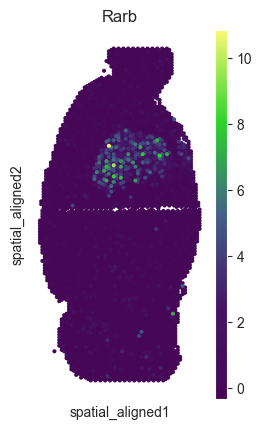

True


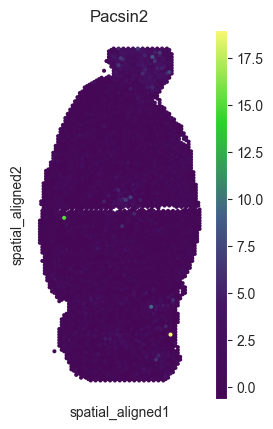

True


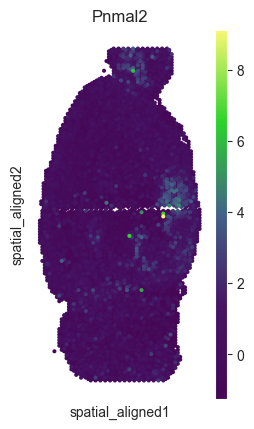

True


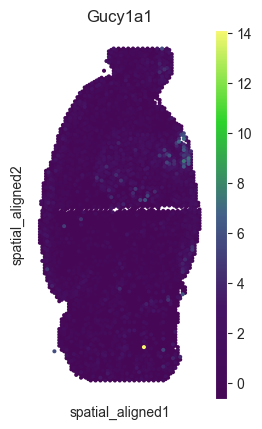

True


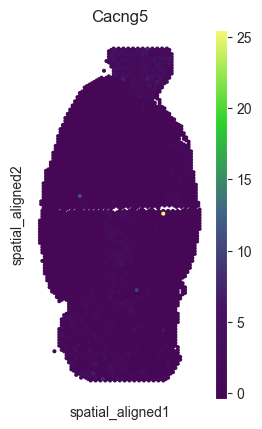

True


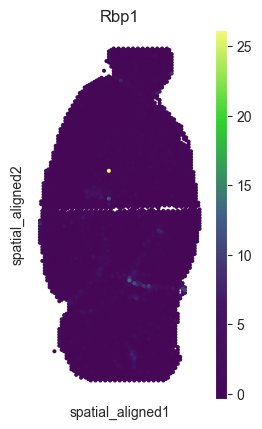

True


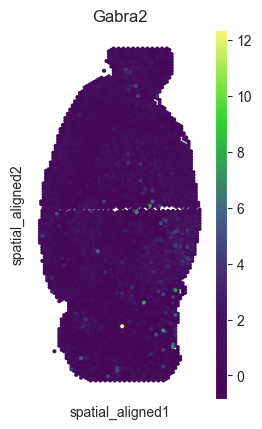

True


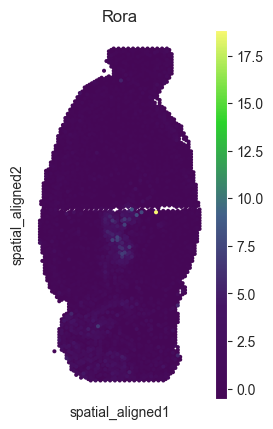

True


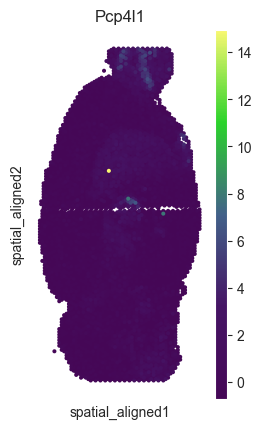

In [32]:
import matplotlib.colors as clr

#gene_list = ['Pgrmc1']

color_self = clr.LinearSegmentedColormap.from_list('pink_green',
                                                   ['#450756', '#451464', '#426189', '#2BD32B', '#F9F871'], N=256)

for gene_raw in g_list:
    print(gene_raw in adata.var.index)  # 检查基因是否存在
    idx = adata.var.index.tolist().index(gene_raw)  #输出基因的idx
    adata.obs[f'{gene_raw}(raw)'] = np.array(adata.X[:, idx]) # 稀疏矩阵转为密集矩阵
    sc_ = sc.pl.spatial(adata, img_key="hires",
                        color=f'{gene_raw}(raw)',
                        title=gene_raw,
                        color_map=color_self,
                        spot_size=200,
                        basis='spatial_aligned')